<img src="../Decorative-Elements/Section-06/ADL-S06-Image-04.png">

<p style="display: flex; justify-content: space-between;">
  <a href="../06-More-Applications/02-Collision-and-Impact-Theory.ipynb" target="_blank">Previous</a>
  <a href="../README.md" target="_blank">Home</a>
</p>

In [1]:
import rebound
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Simulation 1
sim1 = rebound.Simulation()
sim1.units = ('AU', 'yr', 'Msun')

sim1.add(m=1.0)          # Sun
sim1.add(m=1e-3, a=1.0)  # Planet

sim1.move_to_com()

# Simulation 2 (slight change)
sim2 = rebound.Simulation()
sim2.units = ('AU', 'yr', 'Msun')

sim2.add(m=1.0)
sim2.add(m=1e-3, a=1.0001)  # tiny difference

sim2.move_to_com()

In [3]:
times = np.linspace(0, 50, 500)

diff = []  # difference between systems

for t in times:
    sim1.integrate(t)
    sim2.integrate(t)
    
    p1 = sim1.particles[1]
    p2 = sim2.particles[1]
    
    # distance between two simulations
    d = np.sqrt((p1.x - p2.x)**2 + (p1.y - p2.y)**2)
    diff.append(d)

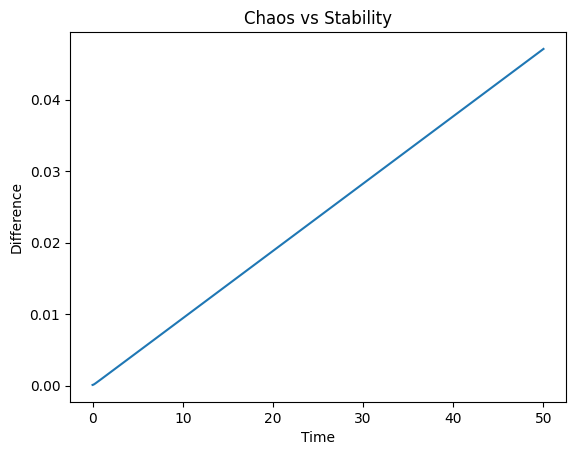

In [4]:
plt.plot(times, diff)

plt.xlabel("Time")
plt.ylabel("Difference")
plt.title("Chaos vs Stability")

plt.show()

In [5]:
if diff[-1] < 0.01:
    print("Stable system: small difference remains small")
else:
    print("Chaotic system: small difference grows")

Chaotic system: small difference grows


In [6]:
# Re-run to store positions
sim1 = rebound.Simulation()
sim1.units = ('AU', 'yr', 'Msun')
sim1.add(m=1.0)
sim1.add(m=1e-3, a=1.0)
sim1.move_to_com()

sim2 = rebound.Simulation()
sim2.units = ('AU', 'yr', 'Msun')
sim2.add(m=1.0)
sim2.add(m=1e-3, a=1.0001)  # small difference
sim2.move_to_com()

times = np.linspace(0, 50, 500)

x1, y1 = [], []
x2, y2 = [], []

for t in times:
    sim1.integrate(t)
    sim2.integrate(t)
    
    p1 = sim1.particles[1]
    p2 = sim2.particles[1]
    
    x1.append(p1.x)
    y1.append(p1.y)
    
    x2.append(p2.x)
    y2.append(p2.y)

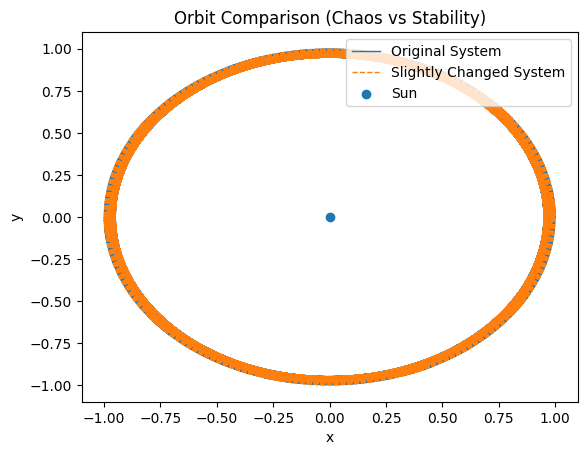

In [7]:
plt.plot(x1, y1, linewidth=1, label="Original System")
plt.plot(x2, y2, linestyle='dashed', linewidth=1, label="Slightly Changed System")

plt.scatter(0, 0, label="Sun")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Orbit Comparison (Chaos vs Stability)")
plt.legend()
plt.legend(loc = "upper right")
plt.show()

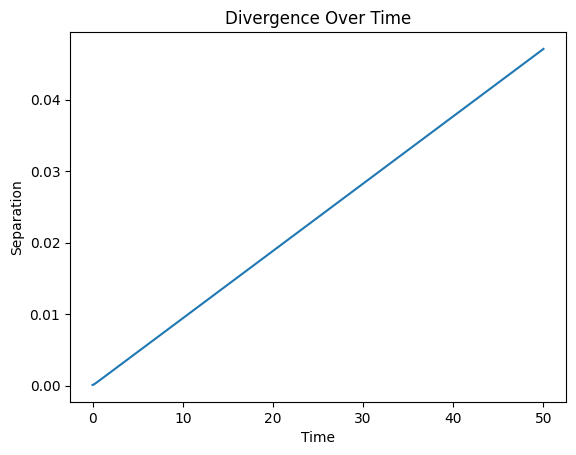

In [8]:
plt.plot(times, diff)

plt.xlabel("Time")
plt.ylabel("Separation")
plt.title("Divergence Over Time")

plt.show()

<p style="display: flex; justify-content: space-between;">
  <a href="../06-More-Applications/02-Collision-and-Impact-Theory.ipynb" target="_blank">Previous</a>
  <a href="../README.md" target="_blank">Home</a>
</p>

<img src="../Decorative-Elements/Section-Footer-Animated/Section-06-03.gif">